In [1]:
# =========================================================
# 필요한 라이브러리 로드
# - pandas : 데이터 처리
# - numpy : 수치 계산
# - matplotlib / seaborn : 시각화
# - StandardScaler : 변수 표준화
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# 출력 옵션 설정 (표가 잘 보이도록)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
# =========================================================
# 데이터 로드
# - 전처리된 BankChurners 데이터 사용
# =========================================================

df = pd.read_csv("preprocessed_BankChurners.csv")

# 데이터 크기 확인
print("데이터 크기:", df.shape)

# 상위 5개 확인
df.head()

데이터 크기: (10127, 20)


,churn,age,gender,dependents,education,marital,income,card_type,relationship_months,product_count,inactive_months,contact_count,credit_limit,revolving_balance,available_credit,amount_change,transaction_amount,transaction_count,count_change,utilization_ratio
0,1,45,0,3,2,2,3,1,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,1,49,1,5,4,1,1,1,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,1,51,0,3,4,2,4,1,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,1,40,1,4,2,4,1,1,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,1,40,0,3,1,2,3,1,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
# =========================================================
# 컬럼 목록 확인
# - 어떤 변수들이 있는지 파악
# =========================================================

df.columns.tolist()

['churn',
 'age',
 'gender',
 'dependents',
 'education',
 'marital',
 'income',
 'card_type',
 'relationship_months',
 'product_count',
 'inactive_months',
 'contact_count',
 'credit_limit',
 'revolving_balance',
 'available_credit',
 'amount_change',
 'transaction_amount',
 'transaction_count',
 'count_change',
 'utilization_ratio']

In [4]:
# =========================================================
# 분석에 사용할 주요 변수 선택
# - churn : 타깃 변수
# - transaction_count : 거래 횟수
# - transaction_amount : 거래 금액
# - credit_limit : 카드 한도
# - utilization_ratio : 사용률
# - inactive_months : 비활성 기간
# - count_change : 거래 변화
# =========================================================

use_cols = [
    "churn",
    "transaction_count",
    "transaction_amount",
    "credit_limit",
    "utilization_ratio",
    "inactive_months",
    "count_change",
    "contact_count",
    "available_credit",
    "revolving_balance"
]

data = df[use_cols].copy()

data.head()

,churn,transaction_count,transaction_amount,credit_limit,utilization_ratio,inactive_months,count_change,contact_count,available_credit,revolving_balance
0,1,42,1144,12691.0,0.061,1,1.625,3,11914.0,777
1,1,33,1291,8256.0,0.105,1,3.714,2,7392.0,864
2,1,20,1887,3418.0,0.000,1,2.333,0,3418.0,0
3,1,20,1171,3313.0,0.760,4,2.333,1,796.0,2517
4,1,28,816,4716.0,0.000,1,2.500,0,4716.0,0


In [5]:
# =========================================================
# 기본 통계량 확인
# - 평균 / 분산 / 최소 / 최대 등
# =========================================================

data.describe().T

,count,mean,std,min,25%,50%,75%,max
churn,10127.0,0.839340,0.367235,0.0,1.000,1.000,1.000,1.000
transaction_count,10127.0,64.858695,23.472570,10.0,45.000,67.000,81.000,139.000
transaction_amount,10127.0,4404.086304,3397.129254,510.0,2155.500,3899.000,4741.000,18484.000
credit_limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
utilization_ratio,10127.0,0.274894,0.275691,0.0,0.023,0.176,0.503,0.999
inactive_months,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
count_change,10127.0,0.712222,0.238086,0.0,0.582,0.702,0.818,3.714
contact_count,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
available_credit,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
revolving_balance,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000


In [6]:
# =========================================================
# 기본 통계량 확인
# - 평균 / 분산 / 최소 / 최대 등
# =========================================================

data.describe().T

,count,mean,std,min,25%,50%,75%,max
churn,10127.0,0.839340,0.367235,0.0,1.000,1.000,1.000,1.000
transaction_count,10127.0,64.858695,23.472570,10.0,45.000,67.000,81.000,139.000
transaction_amount,10127.0,4404.086304,3397.129254,510.0,2155.500,3899.000,4741.000,18484.000
credit_limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
utilization_ratio,10127.0,0.274894,0.275691,0.0,0.023,0.176,0.503,0.999
inactive_months,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
count_change,10127.0,0.712222,0.238086,0.0,0.582,0.702,0.818,3.714
contact_count,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
available_credit,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
revolving_balance,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000


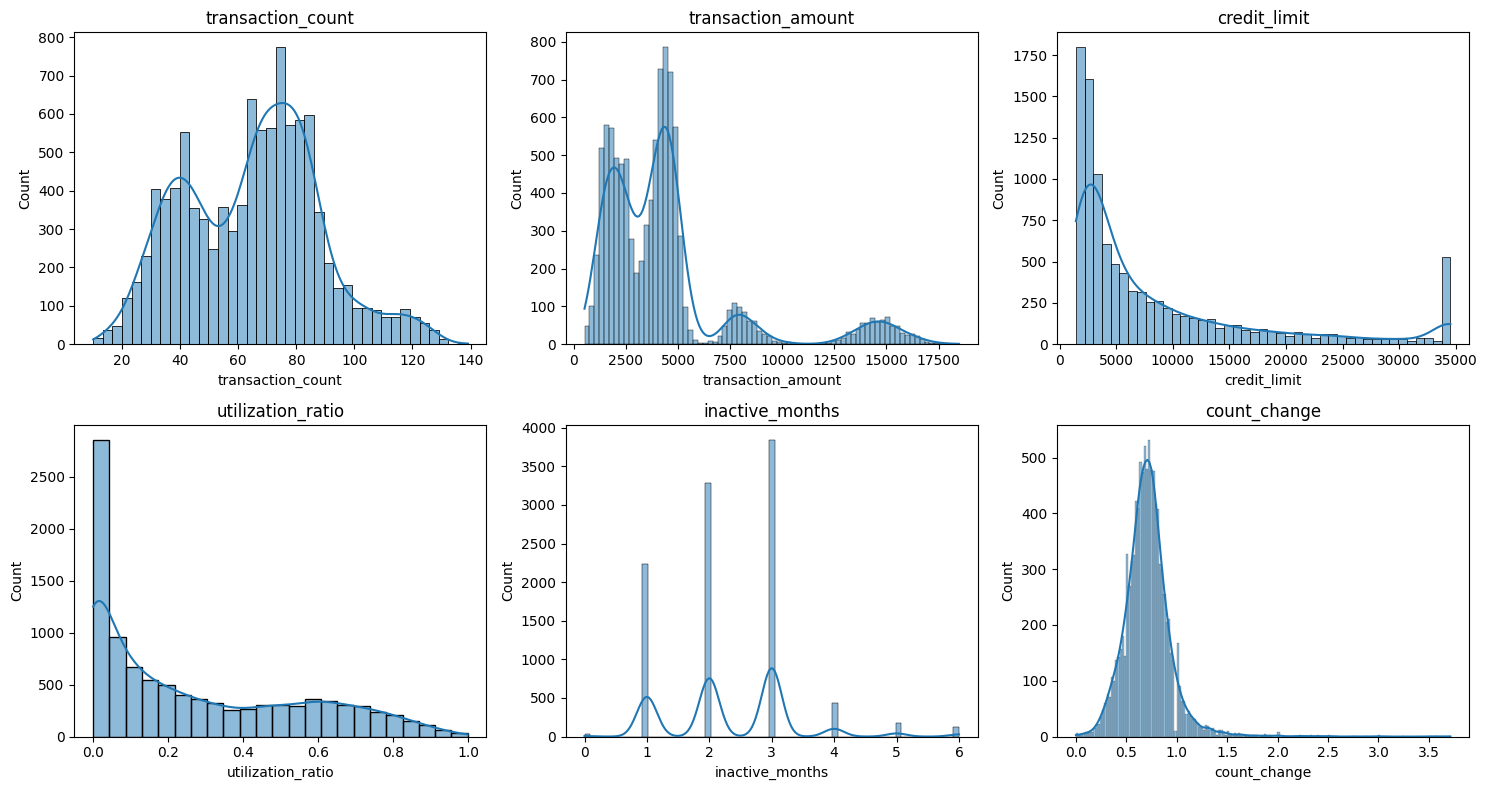

In [7]:
# =========================================================
# 주요 변수 분포 시각화
# - 거래 횟수
# - 거래 금액
# - 카드 한도
# - 사용률
# - 미사용 기간
# - 거래 변화
# =========================================================

fig, axes = plt.subplots(2,3, figsize=(15,8))

cols = [
    "transaction_count",
    "transaction_amount",
    "credit_limit",
    "utilization_ratio",
    "inactive_months",
    "count_change"
]

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [8]:
# =========================================================
# 고객 활동 수준(Activity Score) 계산
# - 거래 횟수
# - 거래 금액
# - 카드 한도
# → 표준화 후 평균값으로 활동 점수 생성
# =========================================================

activity_cols = [
    "transaction_count",
    "transaction_amount",
    "credit_limit"
]

scaler = StandardScaler()

scaled = scaler.fit_transform(data[activity_cols])

scaled_df = pd.DataFrame(
    scaled,
    columns=[c+"_z" for c in activity_cols]
)

data = pd.concat([data, scaled_df], axis=1)

data["activity_score"] = scaled_df.mean(axis=1)

data.head()

,churn,transaction_count,transaction_amount,credit_limit,utilization_ratio,inactive_months,count_change,contact_count,available_credit,revolving_balance,transaction_count_z,transaction_amount_z,credit_limit_z,activity_score
0,1,42,1144,12691.0,0.061,1,1.625,3,11914.0,777,-0.973895,-0.959707,0.446622,-0.495660
1,1,33,1291,8256.0,0.105,1,3.714,2,7392.0,864,-1.357340,-0.916433,-0.041367,-0.771713
2,1,20,1887,3418.0,0.000,1,2.333,0,3418.0,0,-1.911206,-0.740982,-0.573698,-1.075295
3,1,20,1171,3313.0,0.760,4,2.333,1,796.0,2517,-1.911206,-0.951758,-0.585251,-1.149405
4,1,28,816,4716.0,0.000,1,2.500,0,4716.0,0,-1.570365,-1.056263,-0.430877,-1.019169


In [9]:
# =========================================================
# 고객 활동 수준 기준 세그먼트 생성
# - activity_score 기준 사분위수 분할
#
# Dormant  : 저활동 고객
# Casual   : 중간 고객
# Active   : 활동 고객
# Premium  : 고활동 고객
# =========================================================

data["segment"] = pd.qcut(
    data["activity_score"],
    4,
    labels=["Dormant","Casual","Active","Premium"]
)

data["segment"].value_counts()

segment
Dormant    2532
Casual     2532
Premium    2532
Active     2531
Name: count, dtype: int64

In [10]:
# =========================================================
# 세그먼트별 평균 비교
# - 거래 횟수
# - 거래 금액
# - 카드 한도
# - 사용률
# - 비활성 기간
# - churn 비율
# =========================================================

segment_summary = data.groupby("segment").agg({
    "transaction_count":"mean",
    "transaction_amount":"mean",
    "credit_limit":"mean",
    "utilization_ratio":"mean",
    "inactive_months":"mean",
    "count_change":"mean",
    "contact_count":"mean",
    "churn":"mean"
}).round(3)

segment_summary

,transaction_count,transaction_amount,credit_limit,utilization_ratio,inactive_months,count_change,contact_count,churn
segment,,,,,,,,
Dormant,37.206,1806.765,4276.635,0.325,2.410,0.648,2.684,0.602
Casual,60.091,3318.074,6110.517,0.323,2.333,0.727,2.499,0.901
Active,75.310,4282.097,6481.087,0.318,2.330,0.754,2.283,0.963
Premium,86.832,8209.361,17658.726,0.134,2.291,0.720,2.355,0.892


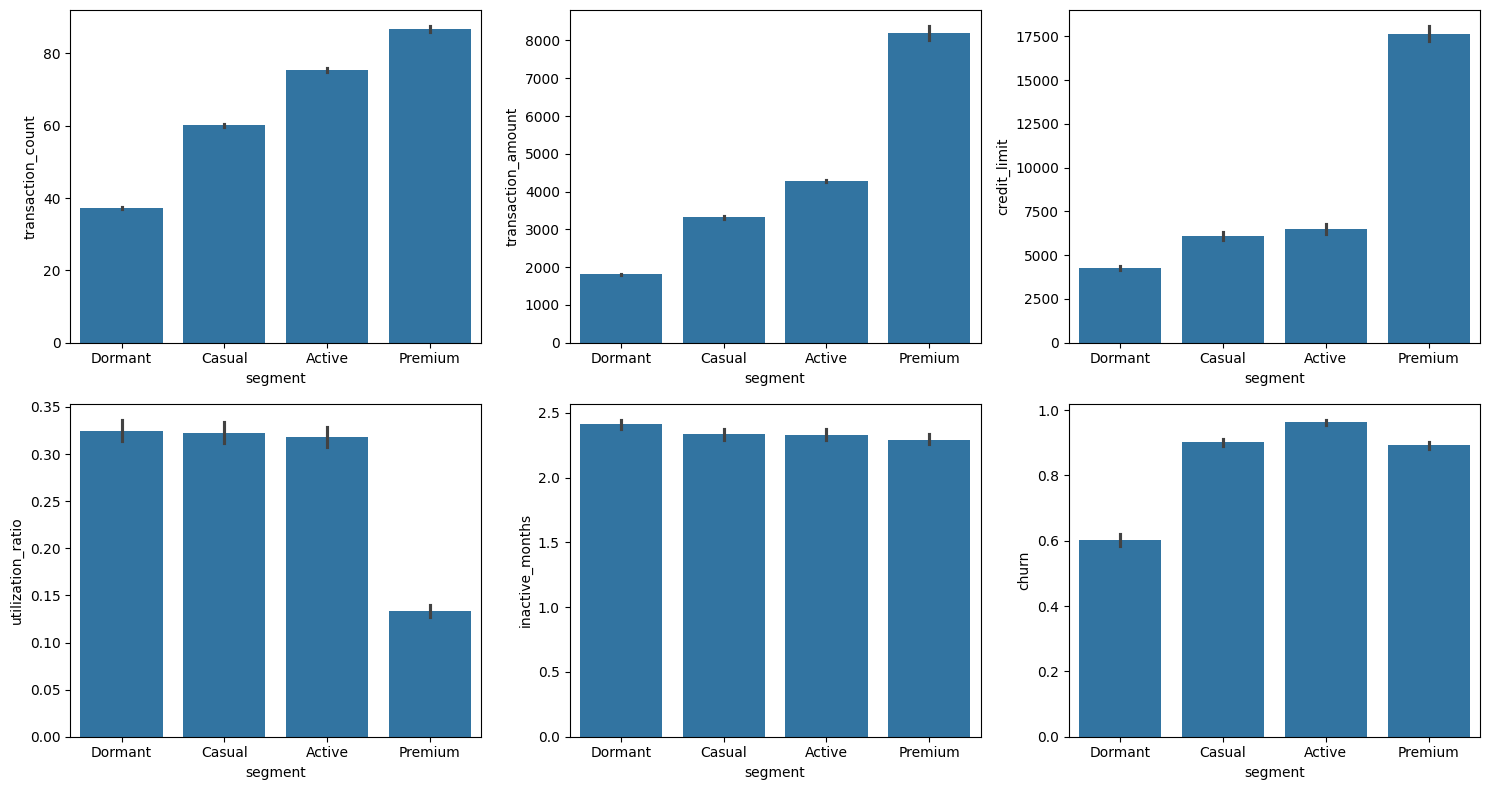

In [11]:
# =========================================================
# 세그먼트별 주요 변수 시각화
# =========================================================

fig, axes = plt.subplots(2,3, figsize=(15,8))

sns.barplot(data=data, x="segment", y="transaction_count", ax=axes[0,0])
sns.barplot(data=data, x="segment", y="transaction_amount", ax=axes[0,1])
sns.barplot(data=data, x="segment", y="credit_limit", ax=axes[0,2])

sns.barplot(data=data, x="segment", y="utilization_ratio", ax=axes[1,0])
sns.barplot(data=data, x="segment", y="inactive_months", ax=axes[1,1])
sns.barplot(data=data, x="segment", y="churn", ax=axes[1,2])

plt.tight_layout()
plt.show()

In [12]:
# =========================================================
# 세그먼트별 churn 비율 확인
# =========================================================

data.groupby("segment")["churn"].mean().sort_values(ascending=False)

segment
Active     0.962861
Casual     0.900869
Premium    0.891785
Dormant    0.601896
Name: churn, dtype: float64

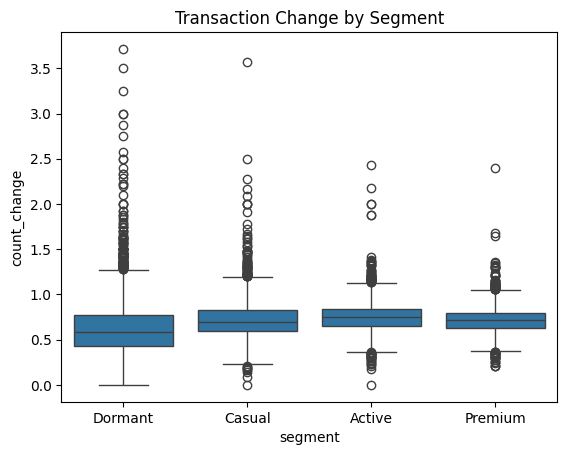

In [13]:
# =========================================================
# 거래 변화(count_change) 분석
# - 세그먼트별 거래 변화 분포 확인
# =========================================================

sns.boxplot(
    data=data,
    x="segment",
    y="count_change"
)

plt.title("Transaction Change by Segment")
plt.show()

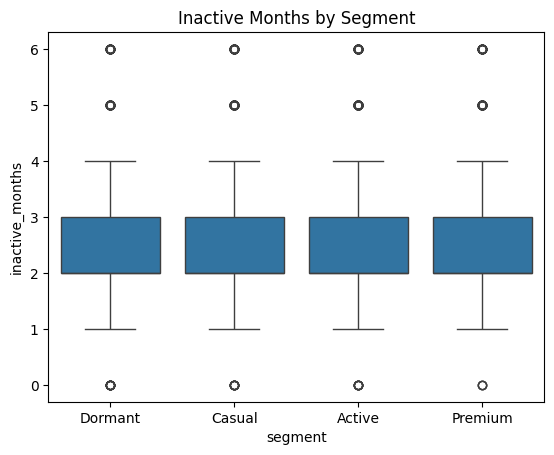

In [14]:
# =========================================================
# 비활성 기간(inactive_months) 분석
# - 세그먼트별 미사용 기간 분포
# =========================================================

sns.boxplot(
    data=data,
    x="segment",
    y="inactive_months"
)

plt.title("Inactive Months by Segment")
plt.show()

In [15]:
# =========================================================
# 고객 가치 점수(Customer Value Score)
# - 거래 금액
# - 거래 횟수
# - 카드 한도
# =========================================================

value_cols = [
    "transaction_amount",
    "transaction_count",
    "credit_limit"
]

scaled_value = scaler.fit_transform(data[value_cols])

value_df = pd.DataFrame(
    scaled_value,
    columns=[c+"_value_z" for c in value_cols]
)

data = pd.concat([data, value_df], axis=1)

data["customer_value_score"] = value_df.mean(axis=1)

data.head()

,churn,transaction_count,transaction_amount,credit_limit,utilization_ratio,inactive_months,count_change,contact_count,available_credit,revolving_balance,transaction_count_z,transaction_amount_z,credit_limit_z,activity_score,segment,transaction_amount_value_z,transaction_count_value_z,credit_limit_value_z,customer_value_score
0,1,42,1144,12691.0,0.061,1,1.625,3,11914.0,777,-0.973895,-0.959707,0.446622,-0.495660,Casual,-0.959707,-0.973895,0.446622,-0.495660
1,1,33,1291,8256.0,0.105,1,3.714,2,7392.0,864,-1.357340,-0.916433,-0.041367,-0.771713,Dormant,-0.916433,-1.357340,-0.041367,-0.771713
2,1,20,1887,3418.0,0.000,1,2.333,0,3418.0,0,-1.911206,-0.740982,-0.573698,-1.075295,Dormant,-0.740982,-1.911206,-0.573698,-1.075295
3,1,20,1171,3313.0,0.760,4,2.333,1,796.0,2517,-1.911206,-0.951758,-0.585251,-1.149405,Dormant,-0.951758,-1.911206,-0.585251,-1.149405
4,1,28,816,4716.0,0.000,1,2.500,0,4716.0,0,-1.570365,-1.056263,-0.430877,-1.019169,Dormant,-1.056263,-1.570365,-0.430877,-1.019169


In [16]:
# =========================================================
# 세그먼트별 고객 가치 비교
# =========================================================

data.groupby("segment")["customer_value_score"].mean()

segment
Dormant   -0.807320
Casual    -0.266758
Active     0.057570
Premium    1.016530
Name: customer_value_score, dtype: float64

In [17]:
# =========================================================
# churn과 변수들의 상관관계 분석
# =========================================================

corr_cols = [
    "churn",
    "transaction_count",
    "transaction_amount",
    "credit_limit",
    "utilization_ratio",
    "inactive_months",
    "count_change",
    "contact_count",
    "customer_value_score",
    "activity_score"
]

corr = data[corr_cols].corr()

corr["churn"].sort_values(ascending=False)

churn                   1.000000
transaction_count       0.371403
count_change            0.290054
customer_value_score    0.249451
activity_score          0.249451
utilization_ratio       0.178410
transaction_amount      0.168598
credit_limit            0.023873
inactive_months        -0.152449
contact_count          -0.204491
Name: churn, dtype: float64

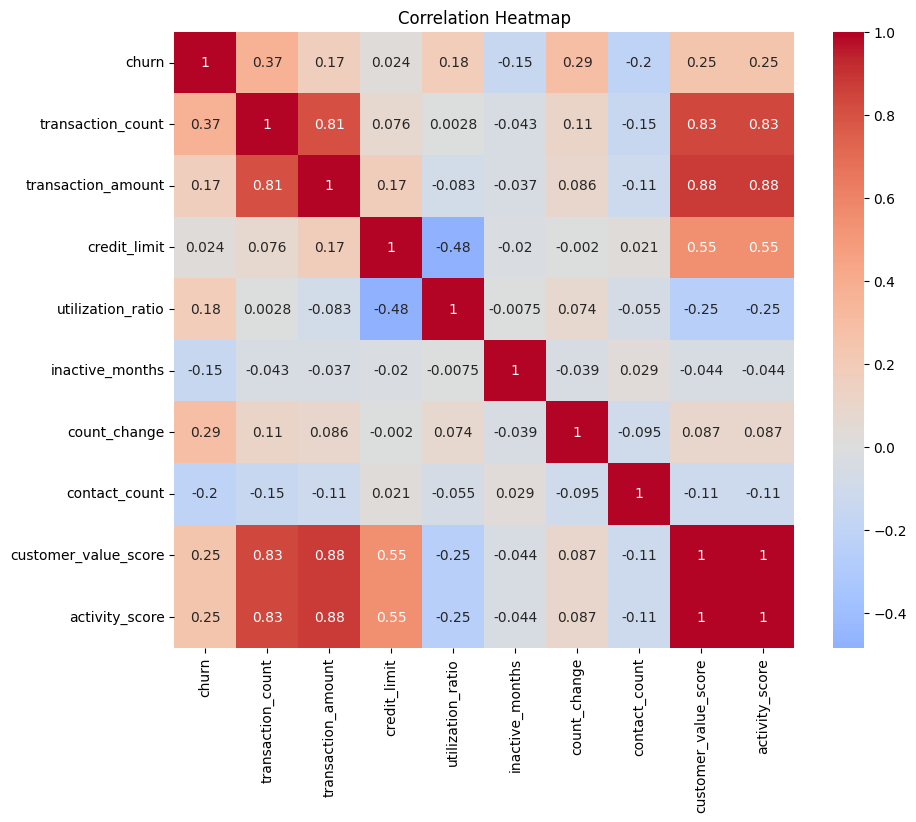

In [18]:
# =========================================================
# 상관관계 히트맵
# =========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

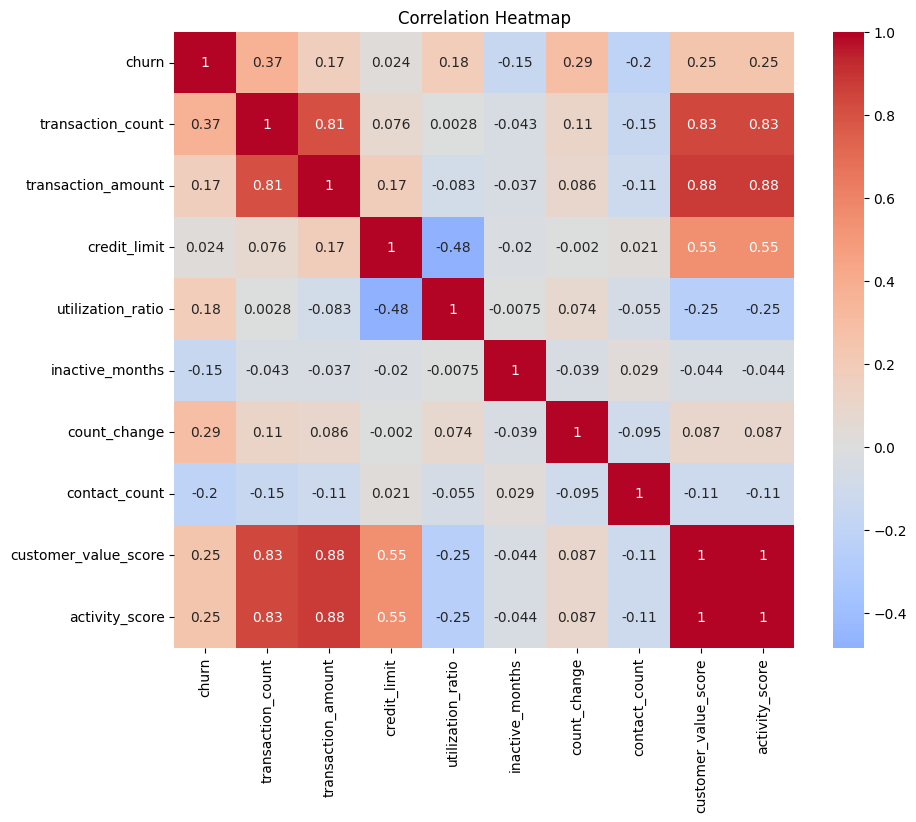

In [19]:
# =========================================================
# 상관관계 히트맵
# =========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [20]:
# =========================================================
# 세그먼트 분류에 사용할 핵심 변수 확인
# - transaction_count   : 거래 빈도
# - transaction_amount  : 소비 규모
# - credit_limit        : 신용 한도
#
# 이 3개 변수를 기준으로 고객의 "활동 수준"을 정의한다.
# =========================================================

segment_base_cols = ["transaction_count", "transaction_amount", "credit_limit"]

print("[세그먼트 분류 기준 변수]")
print(segment_base_cols)

data[segment_base_cols].head()

[세그먼트 분류 기준 변수]
['transaction_count', 'transaction_amount', 'credit_limit']


,transaction_count,transaction_amount,credit_limit
0,42,1144,12691.0
1,33,1291,8256.0
2,20,1887,3418.0
3,20,1171,3313.0
4,28,816,4716.0


In [21]:
# =========================================================
# 세그먼트 분류 기준 변수의 기초통계 확인
# - 변수마다 단위와 범위가 다름
# - 그대로 평균내면 특정 변수(예: credit_limit)가 과도하게 반영될 수 있음
# - 따라서 표준화(Standardization)가 필요함
# =========================================================

data[segment_base_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_count,10127.0,64.858695,23.472570,10.0,45.0,67.0,81.0,139.0
transaction_amount,10127.0,4404.086304,3397.129254,510.0,2155.5,3899.0,4741.0,18484.0
credit_limit,10127.0,8631.953698,9088.776650,1438.3,2555.0,4549.0,11067.5,34516.0


In [22]:
# =========================================================
# 세그먼트 분류 기준 변수의 기초통계 확인
# - 변수마다 단위와 범위가 다름
# - 그대로 평균내면 특정 변수(예: credit_limit)가 과도하게 반영될 수 있음
# - 따라서 표준화(Standardization)가 필요함
# =========================================================

data[segment_base_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_count,10127.0,64.858695,23.472570,10.0,45.0,67.0,81.0,139.0
transaction_amount,10127.0,4404.086304,3397.129254,510.0,2155.5,3899.0,4741.0,18484.0
credit_limit,10127.0,8631.953698,9088.776650,1438.3,2555.0,4549.0,11067.5,34516.0


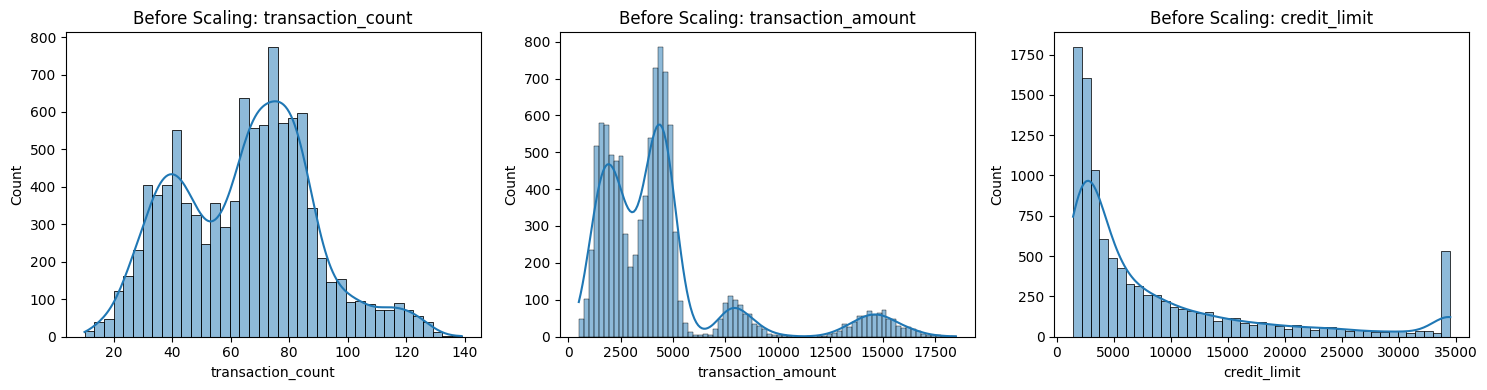

In [23]:
# =========================================================
# 표준화 전 변수 분포 확인
# - 세 변수의 스케일 차이를 시각적으로 확인
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, segment_base_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f"Before Scaling: {col}")

plt.tight_layout()
plt.show()

In [24]:
# =========================================================
# 표준화 후 기초통계 확인
# - 평균이 0 근처인지
# - 표준편차가 1 근처인지 확인
# =========================================================

scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_count_z,10127.0,-1.796178e-16,1.000049,-2.337256,-0.846080,0.091230,0.687701,3.158792
transaction_amount_z,10127.0,-4.490445e-17,1.000049,-1.146344,-0.661940,-0.148688,0.099181,4.144855
credit_limit_z,10127.0,1.234872e-16,1.000049,-0.791527,-0.668655,-0.449252,0.267986,2.848054


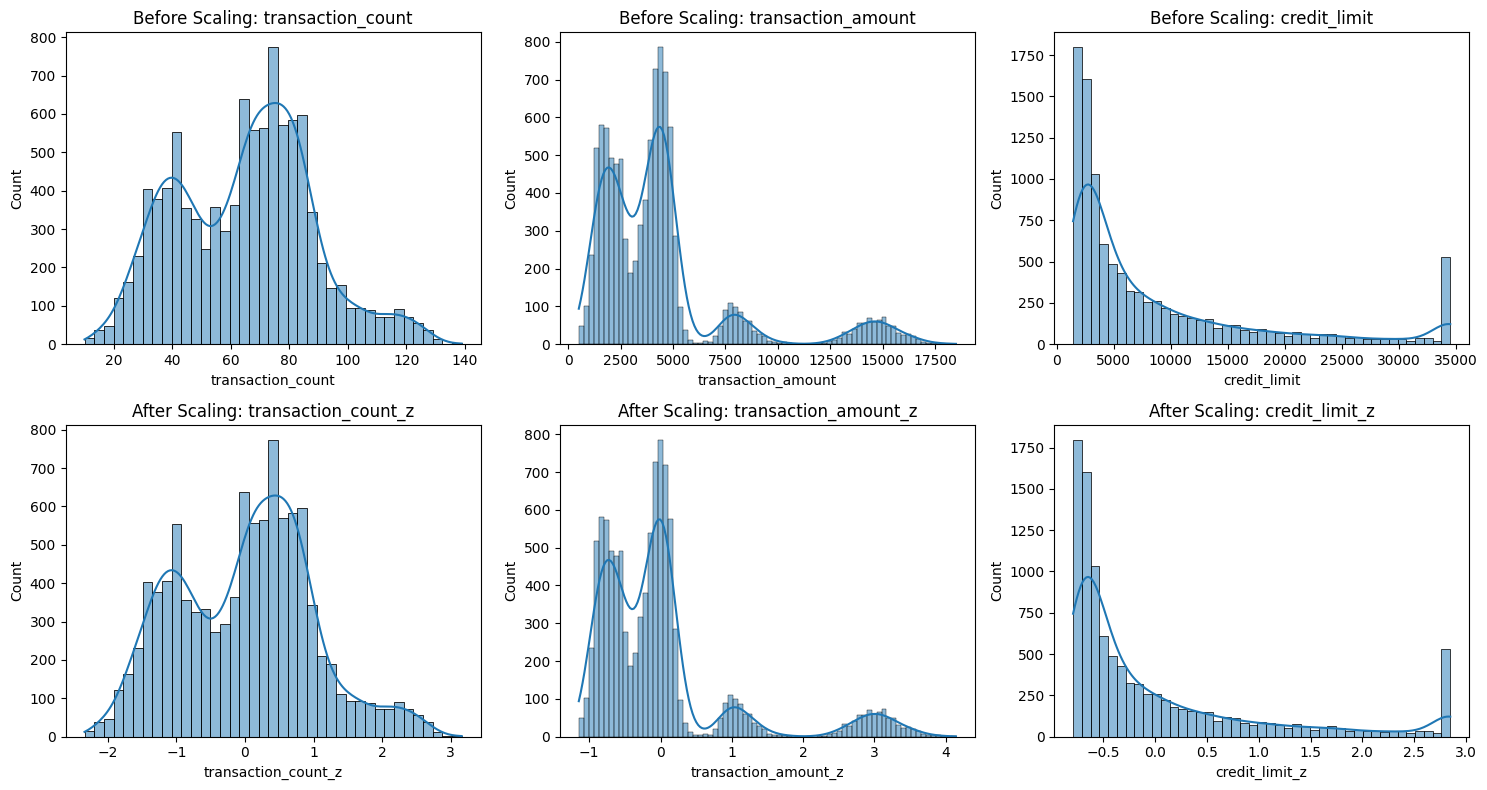

In [25]:
# =========================================================
# 표준화 전후 비교
# - 원본 변수와 표준화 변수의 분포를 비교
# - 발표에서 "왜 표준화했는가"를 설명할 때 활용 가능
# =========================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(segment_base_cols):
    sns.histplot(data[col], kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"Before Scaling: {col}")

for i, col in enumerate(scaled_df.columns):
    sns.histplot(scaled_df[col], kde=True, ax=axes[1, i])
    axes[1, i].set_title(f"After Scaling: {col}")

plt.tight_layout()
plt.show()

In [26]:
# =========================================================
# Activity Score 생성
# - 표준화된 3개 변수의 평균값을 사용
#
# 계산식:
# Activity Score =
# (transaction_count_z + transaction_amount_z + credit_limit_z) / 3
#
# 의미:
# 거래 빈도, 소비 규모, 신용 한도를 종합한
# 고객 활동 수준 지표
# =========================================================

data = pd.concat([data, scaled_df], axis=1)

data["activity_score"] = scaled_df.mean(axis=1)

data[[
    "transaction_count_z",
    "transaction_amount_z",
    "credit_limit_z",
    "activity_score"
]].head()

,transaction_count_z,transaction_count_z,transaction_amount_z,transaction_amount_z,credit_limit_z,credit_limit_z,activity_score
0,-0.973895,-0.973895,-0.959707,-0.959707,0.446622,0.446622,-0.495660
1,-1.357340,-1.357340,-0.916433,-0.916433,-0.041367,-0.041367,-0.771713
2,-1.911206,-1.911206,-0.740982,-0.740982,-0.573698,-0.573698,-1.075295
3,-1.911206,-1.911206,-0.951758,-0.951758,-0.585251,-0.585251,-1.149405
4,-1.570365,-1.570365,-1.056263,-1.056263,-0.430877,-0.430877,-1.019169


count    1.012700e+04
mean    -8.980890e-17
std      7.535253e-01
min     -1.377798e+00
25%     -5.417929e-01
50%     -8.172744e-02
75%      2.259590e-01
max      3.094443e+00
Name: activity_score, dtype: float64


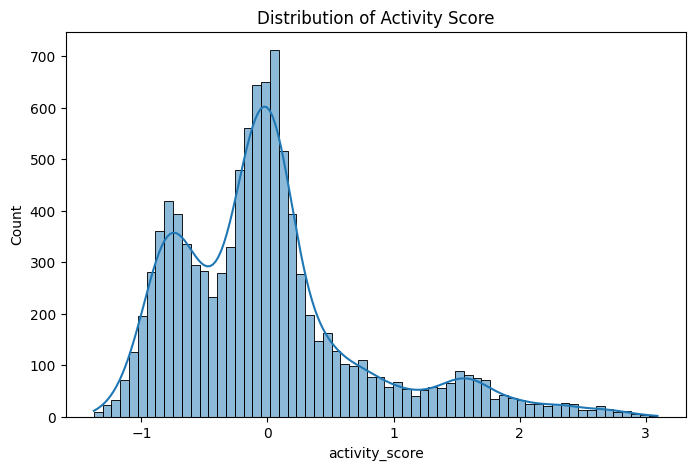

In [27]:
# =========================================================
# Activity Score 분포 확인
# - 고객 활동 수준이 어떻게 분포하는지 확인
# - 이후 이 점수를 기준으로 4개 세그먼트를 나눈다
# =========================================================

print(data["activity_score"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data["activity_score"], kde=True)
plt.title("Distribution of Activity Score")
plt.show()

In [28]:
# =========================================================
# Activity Score의 사분위수 기준값 확인
# - qcut으로 4개 세그먼트를 나누기 전에
#   실제 경계값이 어디인지 확인
#
# 해석:
# 25%, 50%, 75% 지점이
# Dormant / Casual / Active / Premium을 가르는 기준이 된다
# =========================================================

quartiles = data["activity_score"].quantile([0.25, 0.5, 0.75])

print("[Activity Score 사분위수 기준값]")
print(quartiles)

[Activity Score 사분위수 기준값]
0.25   -0.541793
0.50   -0.081727
0.75    0.225959
Name: activity_score, dtype: float64


In [29]:
# =========================================================
# 고객 세그먼트 생성
# - Activity Score를 기준으로 사분위수 분할(qcut)
#
# 구간:
# 하위 25%        -> Dormant
# 25% ~ 50%       -> Casual
# 50% ~ 75%       -> Active
# 상위 25%        -> Premium
# =========================================================

data["segment"] = pd.qcut(
    data["activity_score"],
    4,
    labels=["Dormant", "Casual", "Active", "Premium"]
)

data[["activity_score", "segment"]].head()

,activity_score,segment
0,-0.495660,Casual
1,-0.771713,Dormant
2,-1.075295,Dormant
3,-1.149405,Dormant
4,-1.019169,Dormant


segment
Dormant    2532
Casual     2532
Active     2531
Premium    2532
Name: count, dtype: int64


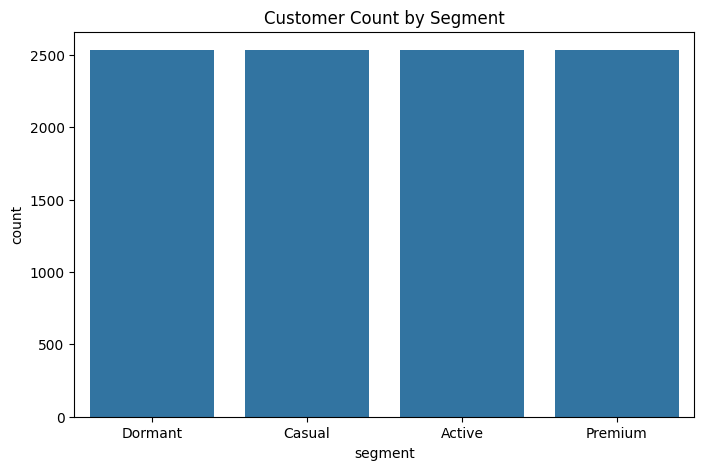

In [30]:
# =========================================================
# 세그먼트별 고객 수 확인
# - 사분위수 기준으로 나눴기 때문에
#   각 세그먼트 인원은 대체로 비슷하게 분포함
# =========================================================

segment_counts = data["segment"].value_counts().sort_index()

print(segment_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="segment", order=["Dormant", "Casual", "Active", "Premium"])
plt.title("Customer Count by Segment")
plt.show()

In [31]:
# =========================================================
# 세그먼트별 Activity Score 범위 확인
# - 각 세그먼트가 실제로 점수상 어떻게 구분되는지 확인
# - min / max / mean을 같이 보면 발표용 표로 쓰기 좋음
# =========================================================

segment_score_summary = data.groupby("segment")["activity_score"].agg(["min", "mean", "max"]).round(3)

segment_score_summary

,min,mean,max
segment,,,
Dormant,-1.378,-0.807,-0.542
Casual,-0.542,-0.267,-0.082
Active,-0.082,0.058,0.226
Premium,0.226,1.017,3.094


In [32]:
# =========================================================
# 세그먼트별 핵심 기준 변수 평균 확인
# - transaction_count
# - transaction_amount
# - credit_limit
#
# 세그먼트가 실제로 활동 수준 차이를 잘 반영하는지 검증
# =========================================================

segment_base_summary = data.groupby("segment")[segment_base_cols].mean().round(2)

segment_base_summary

,transaction_count,transaction_amount,credit_limit
segment,,,
Dormant,37.21,1806.77,4276.63
Casual,60.09,3318.07,6110.52
Active,75.31,4282.10,6481.09
Premium,86.83,8209.36,17658.73


In [33]:
# =========================================================
# 발표용 문장 자동 출력
# - 세그먼트를 어떤 방식으로 분류했는지 한 문장으로 정리
# =========================================================

print("고객 활동 수준을 나타내는 거래 횟수(transaction_count), 거래 금액(transaction_amount), 신용 한도(credit_limit)를 표준화한 뒤,")
print("이들의 평균값을 Activity Score로 정의하고, 이를 사분위수 기준으로 나누어 Dormant, Casual, Active, Premium의 4개 세그먼트를 도출하였다.")

고객 활동 수준을 나타내는 거래 횟수(transaction_count), 거래 금액(transaction_amount), 신용 한도(credit_limit)를 표준화한 뒤,
이들의 평균값을 Activity Score로 정의하고, 이를 사분위수 기준으로 나누어 Dormant, Casual, Active, Premium의 4개 세그먼트를 도출하였다.
